In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv('/content/drive/MyDrive/colab/mlpr/dataset.csv')

display(df.columns)

Index(['timestamp', 'pm25_ugm3', 'pm10_ugm3', 'no_ugm3', 'no2_ugm3', 'nox_ppb',
       'nh3_ugm3', 'so2_ugm3', 'co_mgm3', 'ozone_ugm3', 'at_c', 'rh_pct',
       'ws_ms', 'wd_deg', 'rf_mm', 'tot_rf_mm', 'sr_wm2', 'state', 'city',
       'station', 'station_id', 'latitude', 'longitude', 'era5_sw_down_wm2',
       'era5_dewpoint_k', 'era5_pressure_pa', 'era5_temp_k',
       'era5_cloud_cover', 'era5_precip_m', 'era5_u10_ms', 'era5_v10_ms',
       'era5_temp_c', 'era5_dewpoint_c', 'era5_pressure_hpa', 'era5_precip_mm',
       'era5_wind_speed_ms', 'era5_wind_dir_deg', 'era5_vpd_kpa',
       'era5_rh_pct', 'solar_altitude_deg', 'solar_zenith_deg', 'cos_zenith'],
      dtype='object')

In [4]:
df.drop(columns=['latitude', 'longitude', 'station_id', 'station', 'state', 'city'],  inplace=True)

In [5]:
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('float32')

df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2549291 entries, 0 to 2549290
Data columns (total 36 columns):
 #   Column              Dtype         
---  ------              -----         
 0   timestamp           datetime64[ns]
 1   pm25_ugm3           float32       
 2   pm10_ugm3           float32       
 3   no_ugm3             float32       
 4   no2_ugm3            float32       
 5   nox_ppb             float32       
 6   nh3_ugm3            float32       
 7   so2_ugm3            float32       
 8   co_mgm3             float32       
 9   ozone_ugm3          float32       
 10  at_c                float32       
 11  rh_pct              float32       
 12  ws_ms               float32       
 13  wd_deg              float32       
 14  rf_mm               float32       
 15  tot_rf_mm           float32       
 16  sr_wm2              float32       
 17  era5_sw_down_wm2    float32       
 18  era5_dewpoint_k     float32       
 19  era5_pressure_pa    float32       
 20  er

In [6]:
# Check for missing values
missing_data = df.isnull().sum()
print("Missing values per column:\n", missing_data[missing_data > 0])

# Summary statistics of numerical columns
display(df.describe())

# Check temporal coverage
print(f"Data ranges from {df['timestamp'].min()} to {df['timestamp'].max()}")

Missing values per column:
 Series([], dtype: int64)


,timestamp,pm25_ugm3,pm10_ugm3,no_ugm3,no2_ugm3,nox_ppb,nh3_ugm3,so2_ugm3,co_mgm3,ozone_ugm3,...,era5_dewpoint_c,era5_pressure_hpa,era5_precip_mm,era5_wind_speed_ms,era5_wind_dir_deg,era5_vpd_kpa,era5_rh_pct,solar_altitude_deg,solar_zenith_deg,cos_zenith
count,2549291,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,...,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06
mean,2024-07-12 02:14:47.580429824,4.188275e+01,9.484842e+01,8.817250e+00,1.769503e+01,1.928344e+01,2.083845e+01,1.228526e+01,6.984427e-01,3.972440e+01,...,1.911414e+01,9.776608e+02,1.703613e-01,2.627517e+00,1.973055e+02,1.674933e+00,6.202049e+01,3.747908e+01,5.252092e+01,5.630006e-01
min,2023-01-01 07:00:00,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,...,-1.970654e+01,8.029435e+02,0.000000e+00,1.467543e-03,0.000000e+00,0.000000e+00,1.990431e+00,7.010949e-06,1.012989e-01,1.223641e-07
25%,2023-10-23 07:00:00,1.866667e+01,4.688000e+01,1.925000e+00,7.260000e+00,6.837500e+00,8.510000e+00,4.160000e+00,3.400000e-01,1.584000e+01,...,1.427704e+01,9.627969e+02,0.000000e+00,1.509653e+00,1.002838e+02,6.774687e-01,4.573385e+01,1.918246e+01,3.640986e+01,3.285776e-01
50%,2024-07-10 10:00:00,3.109000e+01,7.575000e+01,3.975000e+00,1.309000e+01,1.252500e+01,1.568000e+01,8.000000e+00,5.550000e-01,3.077000e+01,...,2.018604e+01,9.819400e+02,0.000000e+00,2.366550e+00,2.269820e+02,1.317940e+00,6.479462e+01,3.727040e+01,5.272960e+01,6.055774e-01
75%,2025-04-04 18:00:00,5.232000e+01,1.209900e+02,8.290000e+00,2.237500e+01,2.240000e+01,2.670250e+01,1.486667e+01,8.600000e-01,5.447750e+01,...,2.459488e+01,9.972018e+02,4.100800e-02,3.493125e+00,2.837038e+02,2.246976e+00,7.939188e+01,5.359014e+01,7.081754e+01,8.047917e-01
max,2025-12-31 18:00:00,1.000000e+03,1.000000e+03,5.000000e+02,4.960200e+02,4.999400e+02,4.934200e+02,2.000000e+02,2.979750e+01,4.956700e+02,...,3.128574e+01,1.022125e+03,3.618717e+01,1.434470e+01,3.599995e+02,1.138882e+01,1.000000e+02,8.989870e+01,8.999999e+01,9.999985e-01
std,NaN,4.055224e+01,7.454008e+01,2.438113e+01,1.805892e+01,2.903597e+01,2.016551e+01,1.450794e+01,6.230684e-01,3.255500e+01,...,6.177508e+00,3.231558e+01,6.860947e-01,1.499462e+00,1.018352e+02,1.347383e+00,2.090220e+01,2.206181e+01,2.206203e+01,2.856436e-01


Data ranges from 2023-01-01 07:00:00 to 2025-12-31 18:00:00


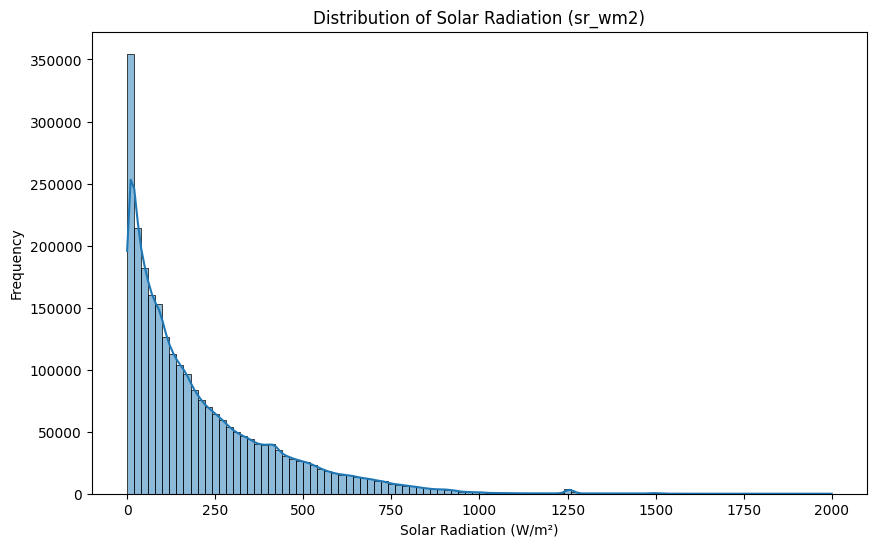

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sr_wm2'].dropna(), bins=100, kde=True)
plt.title('Distribution of Solar Radiation (sr_wm2)')
plt.xlabel('Solar Radiation (W/m²)')
plt.ylabel('Frequency')
plt.show()

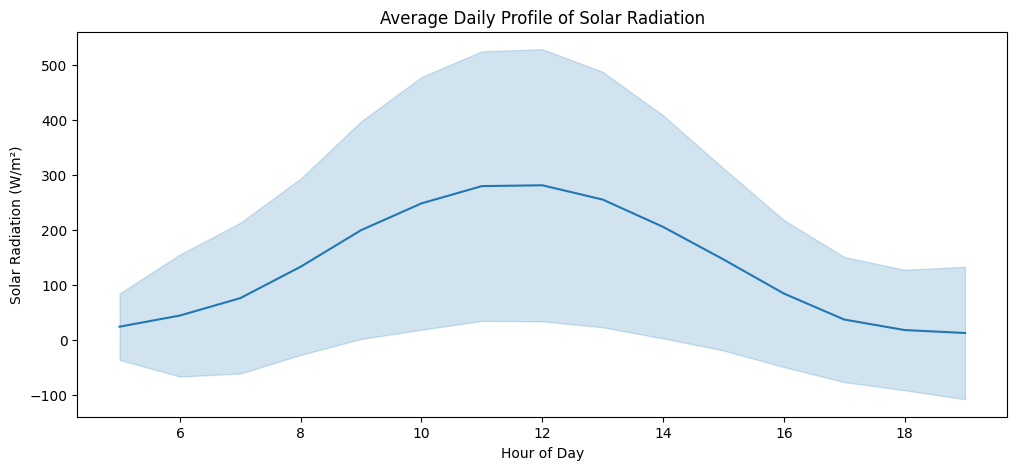

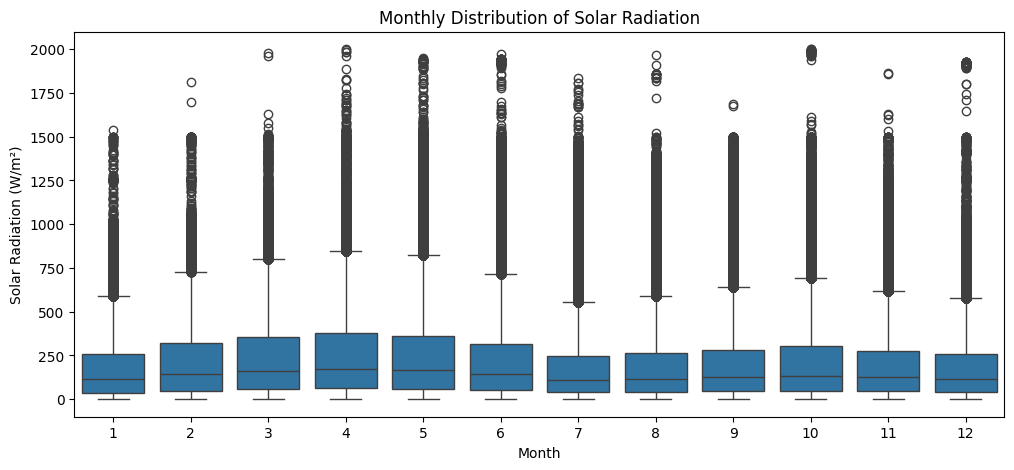

In [11]:
# Extract time features
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

# 1. Daily Profile
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour', y='sr_wm2', estimator=np.median, errorbar='sd')
plt.title('Average Daily Profile of Solar Radiation')
plt.xlabel('Hour of Day')
plt.ylabel('Solar Radiation (W/m²)')
plt.show()

# 2. Monthly Profile (Seasonality)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='month', y='sr_wm2')
plt.title('Monthly Distribution of Solar Radiation')
plt.xlabel('Month')
plt.ylabel('Solar Radiation (W/m²)')
plt.show()

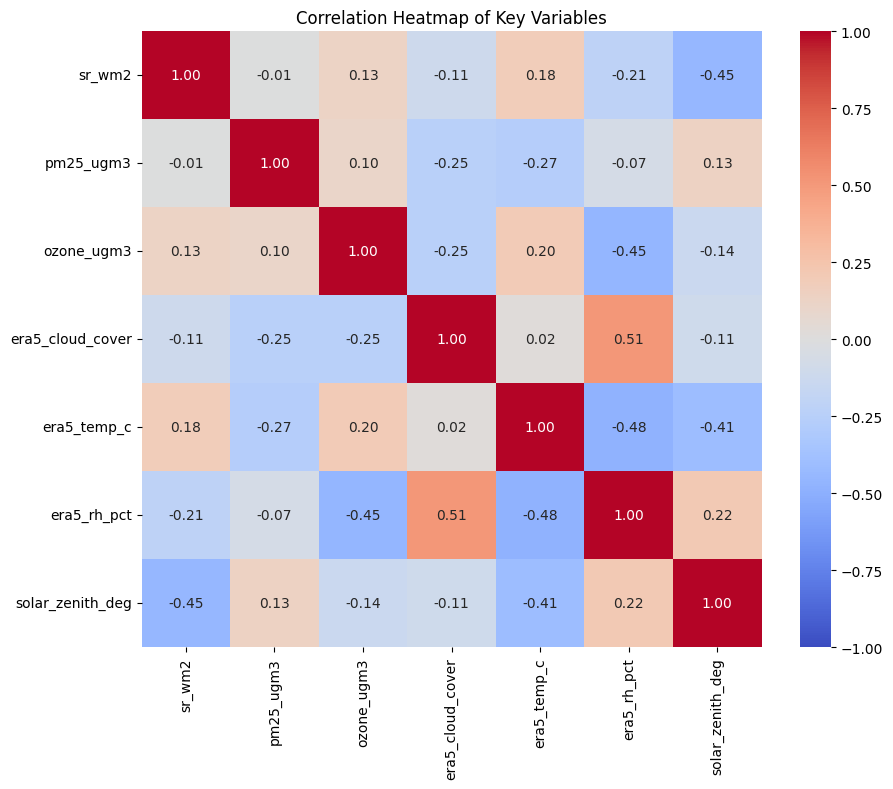

In [12]:
# Select key numerical columns for correlation (excluding ID columns)
cols_for_corr = ['sr_wm2', 'pm25_ugm3', 'ozone_ugm3', 'era5_cloud_cover', 
                 'era5_temp_c', 'era5_rh_pct', 'solar_zenith_deg']

corr_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Variables')
plt.show()

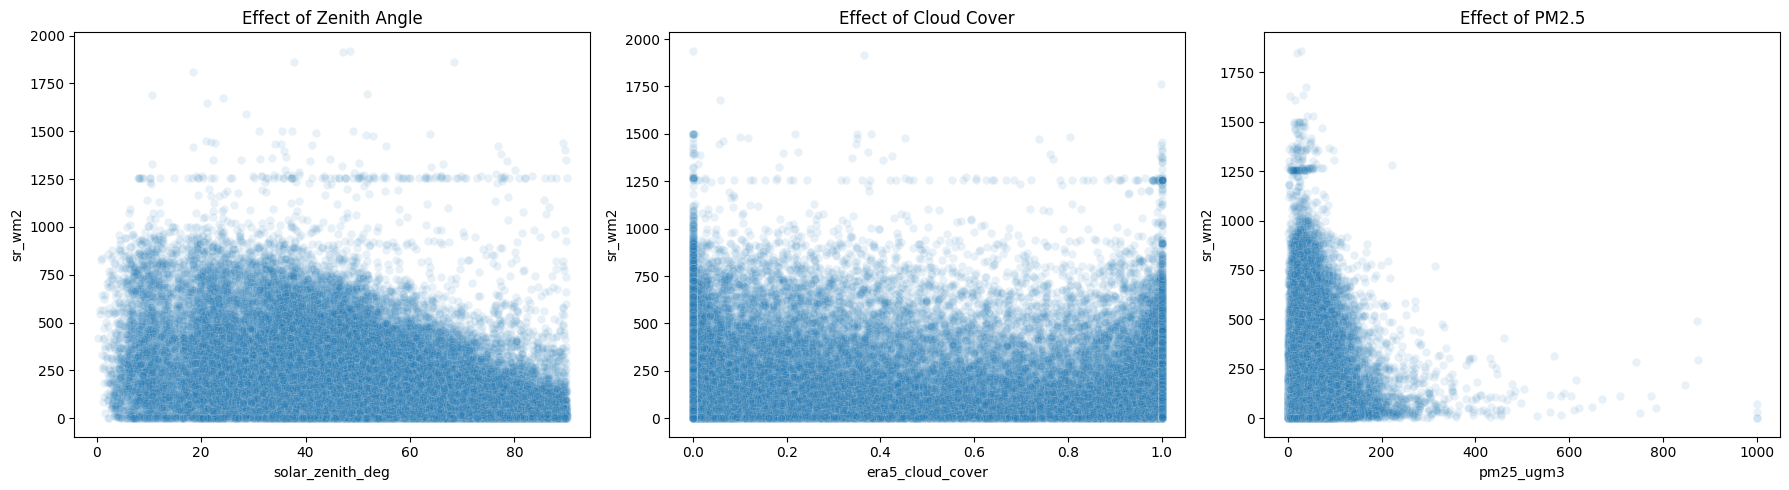

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Solar Radiation vs. Solar Zenith Angle
sns.scatterplot(data=df.sample(50000), x='solar_zenith_deg', y='sr_wm2', ax=axes[0], alpha=0.1)
axes[0].set_title('Effect of Zenith Angle')

# Solar Radiation vs. Cloud Cover
sns.scatterplot(data=df.sample(50000), x='era5_cloud_cover', y='sr_wm2', ax=axes[1], alpha=0.1)
axes[1].set_title('Effect of Cloud Cover')

# Solar Radiation vs. PM2.5 (Aerosol scattering)
sns.scatterplot(data=df.sample(50000), x='pm25_ugm3', y='sr_wm2', ax=axes[2], alpha=0.1)
axes[2].set_title('Effect of PM2.5')

plt.tight_layout()
plt.show()

Starting training...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.332552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8480
[LightGBM] [Info] Number of data points in the train set: 2039432, number of used features: 37
[LightGBM] [Info] Start training from score 205.421282
Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 159.52	valid_1's rmse: 159.604
[100]	training's rmse: 148.29	valid_1's rmse: 148.448
[150]	training's rmse: 141.725	valid_1's rmse: 141.921
[200]	training's rmse: 137.62	valid_1's rmse: 137.898
[250]	training's rmse: 134.625	valid_1's rmse: 135.006
[300]	training's rmse: 132.312	valid_1's rmse: 132.834
[350]	training's rmse: 130.373	valid_1's rmse: 131.014
[400]	training's rmse: 128.723	valid_1's rmse: 129.484
[450]	training's rmse: 127.053	valid_1's rmse: 127.92
[500]	training's rmse: 125.671	valid_1's rmse: 126.654
[550]	training's rmse: 124.

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

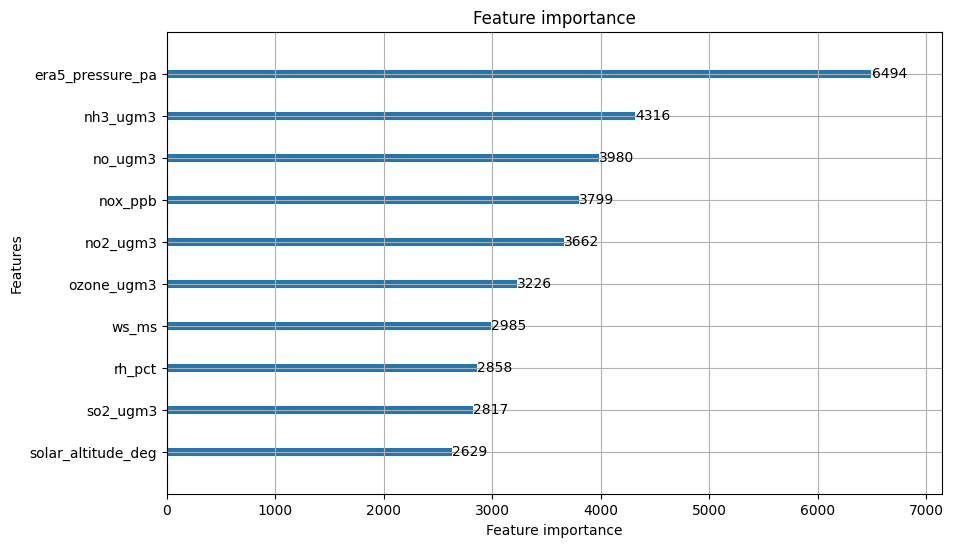

In [17]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour


cols_to_drop = ['sr_wm2', 'era5_sw_down_wm2', 'timestamp']
X = df.drop(columns=cols_to_drop)
y = df['sr_wm2']

# 3. Train/Test Split
# Reserving 20% of 2.5 million rows still leaves you with a massive 500k testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Create LightGBM Datasets
# This format is highly optimized for memory and speed
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 5. Define Model Parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',           # Root Mean Squared Error
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,           # Allows the model to learn complex patterns
    'feature_fraction': 0.8,    # Uses 80% of features per tree to prevent overfitting
    'n_jobs': -1                # Uses all available CPU cores
}

# 6. Train the Model
print("Starting training...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

# 7. Predictions & Evaluation
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"RMSE: {rmse:.2f} W/m²")
print(f"MAE:  {mae:.2f} W/m²")
print(f"R² Score: {r2:.4f}")

# 8. Feature Importance
print("\nTop 10 Most Important Features:")
lgb.plot_importance(model, max_num_features=10, figsize=(10, 6))

Calculating SHAP values...


Generating Force Plot...
Generating Summary Plot...


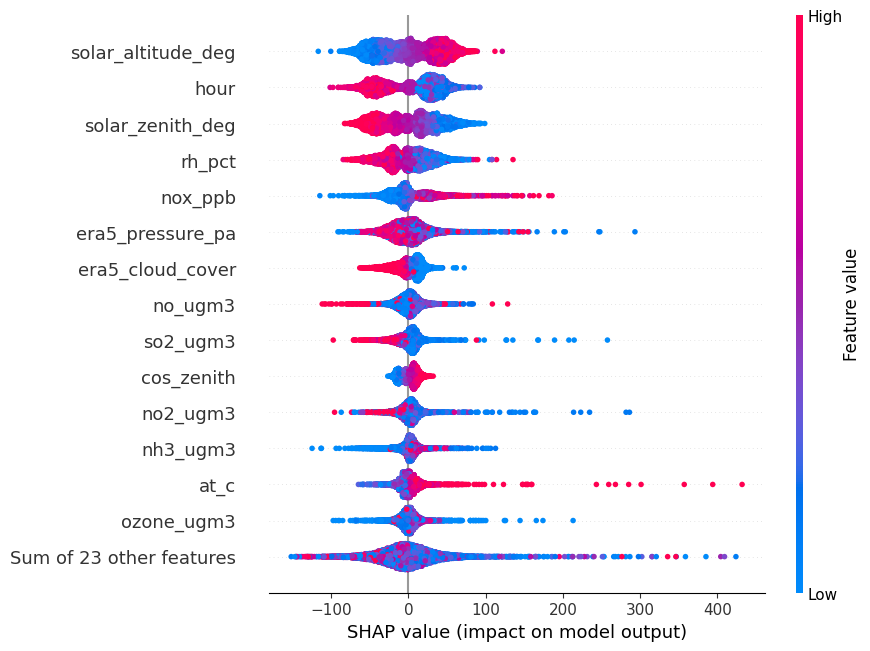

Generating Dependence Plot...


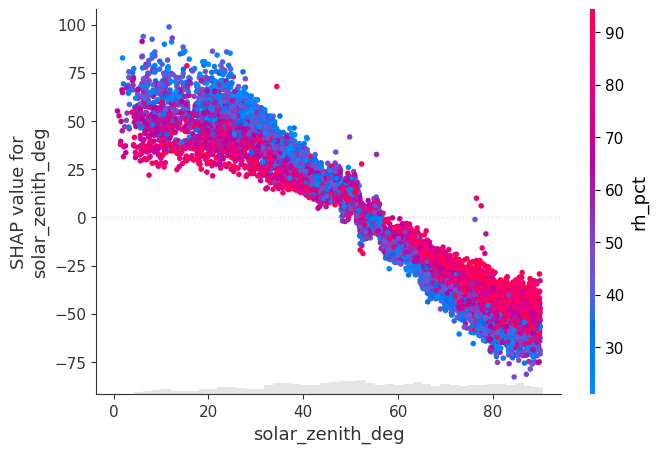

In [ ]:
import shap

X_shap = X_test.sample(n=10000, random_state=42)

explainer = shap.TreeExplainer(model)

print("Calculating SHAP values...")
shap_values = explainer(X_shap)

# PLOT 1: FORCE PLOT (Single Prediction)
shap.initjs()

print("Generating Force Plot...")
shap.plots.force(shap_values[0])


# PLOT 2: SUMMARY PLOT (Overall Importance)
print("Generating Summary Plot...")
# A beeswarm plot shows both the rank of importance AND the directional impact
shap.plots.beeswarm(shap_values, max_display=15)

# PLOT 3: DEPENDENCE PLOT (Feature Effect)
print("Generating Dependence Plot...")
shap.plots.scatter(shap_values[:, "solar_zenith_deg"], color=shap_values)
# shap.plots.scatter(shap_values[:, "era5_cloud_cover"], color=shap_values)
# shap.plots.scatter(shap_values[:, "pm25_ugm3"], color=shap_values)

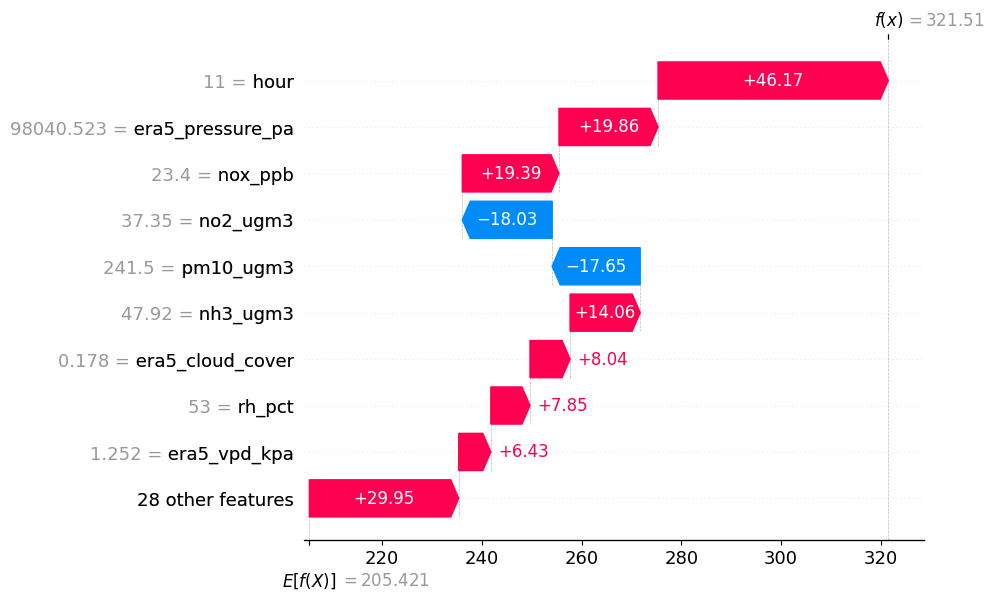

In [19]:
shap.plots.waterfall(shap_values[0])